# Decision Tree CART Example on IRIS Data set

In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [4]:
print("=" * 60)
print("CART DECISION TREE EXPLANATION")
print("=" * 60)

CART DECISION TREE EXPLANATION


In [5]:
# Load the Iris dataset
print("\n1. Loading Iris Dataset...")
iris = load_iris()
X = iris.data
y = iris.target


1. Loading Iris Dataset...


In [6]:
# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)


In [7]:
print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(df['species'].value_counts())


Dataset shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [8]:
print("\n2. Splitting data into training (70%) and testing (30%) sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


2. Splitting data into training (70%) and testing (30%) sets...


In [9]:
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# Create and train CART Decision Tree
print("\n3. Training CART Decision Tree Classifier...")
print("\nCART Algorithm works by:")
print("  - Recursively splitting data based on feature values")
print("  - Using Gini impurity as the splitting criterion")
print("  - Creating binary splits (yes/no decisions)")
print("  - Stopping when a stopping criterion is met")

Training samples: 105, Testing samples: 45

3. Training CART Decision Tree Classifier...

CART Algorithm works by:
  - Recursively splitting data based on feature values
  - Using Gini impurity as the splitting criterion
  - Creating binary splits (yes/no decisions)
  - Stopping when a stopping criterion is met


In [10]:
clf = DecisionTreeClassifier(
    criterion='gini',      # CART uses Gini impurity
    max_depth=3,           # Limit depth to avoid overfitting
    min_samples_split=2,   # Minimum samples to split a node
    random_state=42
)



Tree depth: 3
Number of leaves: 5

4. Making predictions on test set...

5. Model Evaluation:

Accuracy: 0.9778 (97.78%)

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


6. Feature Importance:
             feature  importance
2  petal length (cm)    0.550877
3   petal width (cm)    0.449123
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000

7. Visualizing the Decision Tree...
Tree visualization saved as 'decision_tree.png'


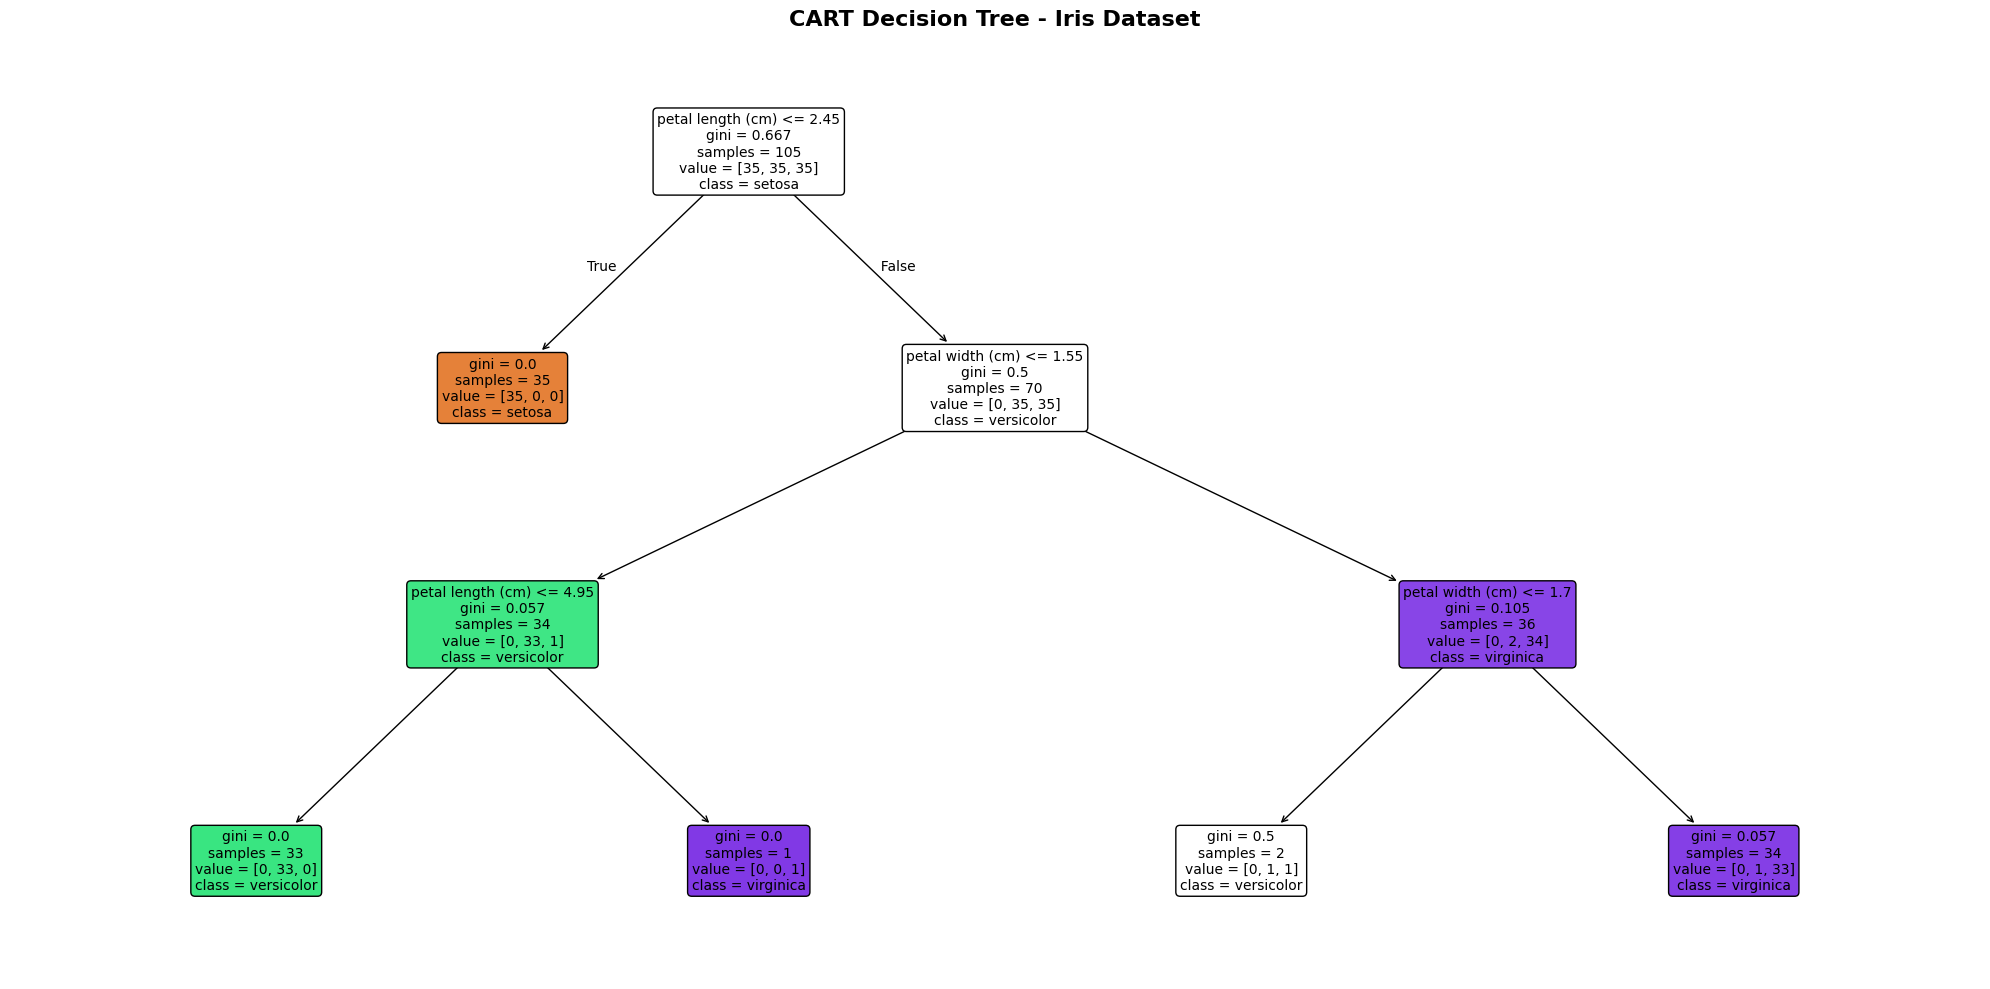


8. Example Prediction:

Sample features: [7.3 2.9 6.3 1.8]
Predicted class: virginica
Actual class: virginica

Class probabilities:
  setosa: 0.0000
  versicolor: 0.0294
  virginica: 0.9706

KEY CONCEPTS OF CART DECISION TREES

1. GINI IMPURITY: Measures node impurity (0 = pure, 0.5 = max impurity)
   Formula: Gini = 1 - Σ(pi²) where pi is probability of class i

2. SPLITTING: At each node, algorithm finds the best feature and 
   threshold that minimizes weighted Gini impurity of child nodes

3. BINARY TREE: Each internal node has exactly two children (yes/no)

4. STOPPING CRITERIA: Tree stops growing when:
   - Maximum depth is reached
   - Minimum samples per node is reached
   - Node is pure (all samples belong to one class)

5. PREDICTION: Follow decision path from root to leaf based on 
   feature values, return majority class in the leaf node



In [11]:
clf.fit(X_train, y_train)
print("\nTree depth:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())

# Make predictions
print("\n4. Making predictions on test set...")
y_pred = clf.predict(X_test)

# Evaluate the model
print("\n5. Model Evaluation:")
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Feature importance
print("\n6. Feature Importance:")
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

# Visualize the tree
print("\n7. Visualizing the Decision Tree...")
plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("CART Decision Tree - Iris Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=300, bbox_inches='tight')
print("Tree visualization saved as 'decision_tree.png'")
plt.show()

# Example prediction with explanation
print("\n8. Example Prediction:")
sample_idx = 0
sample = X_test[sample_idx].reshape(1, -1)
prediction = clf.predict(sample)
probabilities = clf.predict_proba(sample)

print(f"\nSample features: {sample[0]}")
print(f"Predicted class: {iris.target_names[prediction[0]]}")
print(f"Actual class: {iris.target_names[y_test[sample_idx]]}")
print(f"\nClass probabilities:")
for i, prob in enumerate(probabilities[0]):
    print(f"  {iris.target_names[i]}: {prob:.4f}")

# Key concepts explanation
print("\n" + "=" * 60)
print("KEY CONCEPTS OF CART DECISION TREES")
print("=" * 60)
print("""
1. GINI IMPURITY: Measures node impurity (0 = pure, 0.5 = max impurity)
   Formula: Gini = 1 - Σ(pi²) where pi is probability of class i

2. SPLITTING: At each node, algorithm finds the best feature and
   threshold that minimizes weighted Gini impurity of child nodes

3. BINARY TREE: Each internal node has exactly two children (yes/no)

4. STOPPING CRITERIA: Tree stops growing when:
   - Maximum depth is reached
   - Minimum samples per node is reached
   - Node is pure (all samples belong to one class)

5. PREDICTION: Follow decision path from root to leaf based on
   feature values, return majority class in the leaf node
""")

#Hyperparameter Fine Tuning Example

                         DECISION TREE - COMPLETE GUIDE
                    Complex Real-World Dataset Analysis

PART 1: FUNDAMENTAL CONCEPTS OF DECISION TREES

╔════════════════════════════════════════════════════════════════════════════╗
║                    WHAT IS A DECISION TREE?                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

A decision tree is a supervised learning algorithm that creates a flowchart-like
structure where:
  • Each INTERNAL NODE represents a test on a feature
  • Each BRANCH represents the outcome of the test
  • Each LEAF NODE represents a class label or predicted value

Example Decision Process:
    [Age > 30?]
    /         \
  Yes         No
   |           |
[Income>50k?] [Student?]
  /    \       /    \
High  Low   Yes   No

╔════════════════════════════════════════════════════════════════════════════╗
║                    TREE STRUCTURE COMPONENTS                                ║
╚════════════

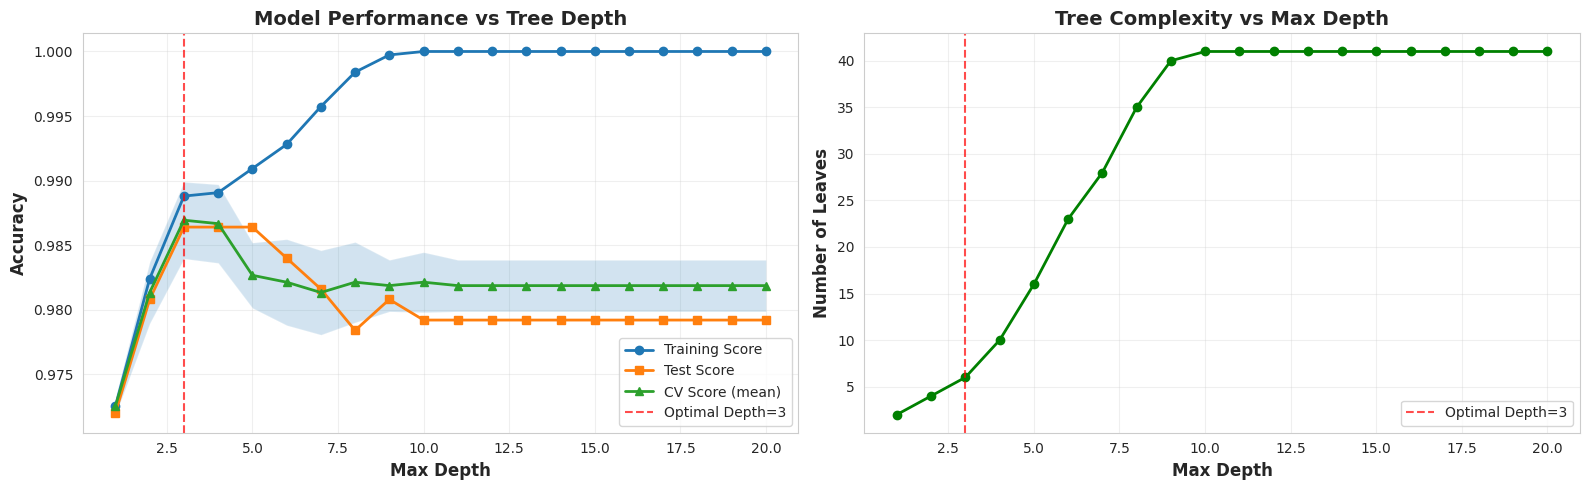


──────────────────────────────────────────────────────────────────────────────────────────
DETAILED RESULTS TABLE
──────────────────────────────────────────────────────────────────────────────────────────
 Depth Train Acc Test Acc CV Mean CV Std  Leaves Overfit Gap
     1    0.9725   0.9720  0.9725 0.0007       2      0.0005
     2    0.9824   0.9808  0.9813 0.0024       4      0.0016
     3    0.9888   0.9864  0.9869 0.0030       6      0.0024
     4    0.9891   0.9864  0.9867 0.0030      10      0.0027
     5    0.9909   0.9864  0.9827 0.0025      16      0.0045
     6    0.9928   0.9840  0.9821 0.0033      23      0.0088
     7    0.9957   0.9816  0.9813 0.0033      28      0.0141
     8    0.9984   0.9784  0.9821 0.0031      35      0.0200
     9    0.9997   0.9808  0.9819 0.0020      40      0.0189
    10    1.0000   0.9792  0.9821 0.0023      41      0.0208
    11    1.0000   0.9792  0.9819 0.0020      41      0.0208
    12    1.0000   0.9792  0.9819 0.0020      41      0.0208
 

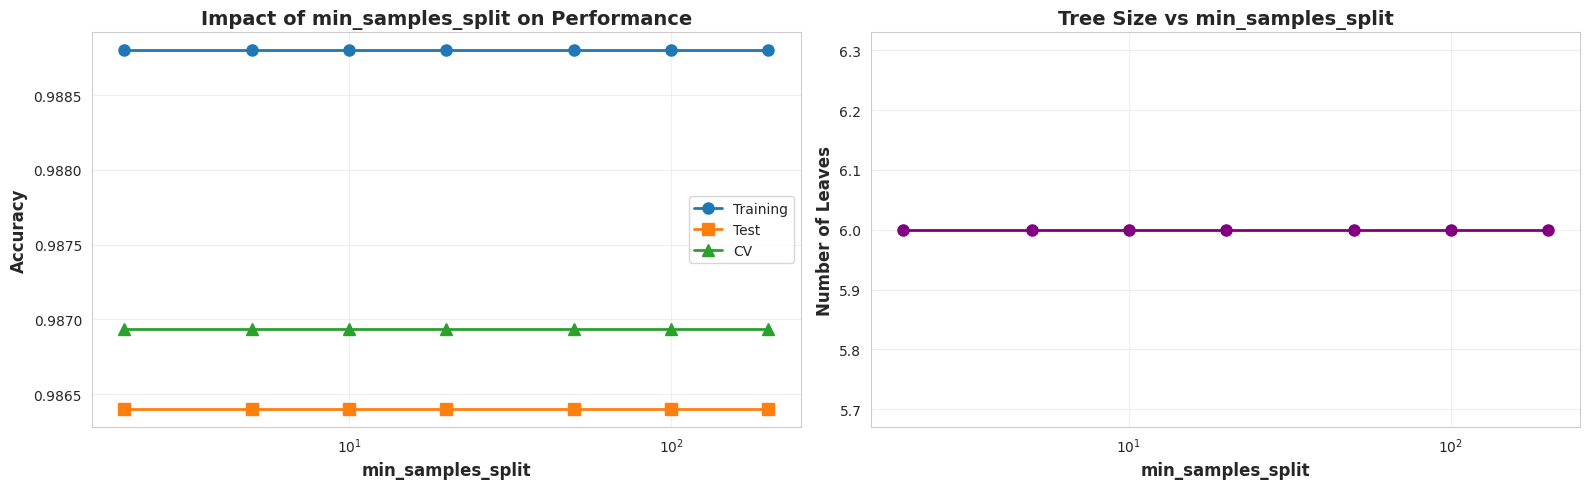


EXPERIMENT 4: MIN_SAMPLES_LEAF IMPACT

Testing different min_samples_leaf values...
min_samples_leaf=  1: Train=0.9888, Test=0.9864, Leaves=6
min_samples_leaf=  5: Train=0.9888, Test=0.9864, Leaves=6
min_samples_leaf= 10: Train=0.9888, Test=0.9864, Leaves=6
min_samples_leaf= 20: Train=0.9888, Test=0.9864, Leaves=6
min_samples_leaf= 50: Train=0.9848, Test=0.9752, Leaves=6
min_samples_leaf=100: Train=0.9731, Test=0.9728, Leaves=6

📊 Plot saved as 'experiment4_min_samples_leaf.png'


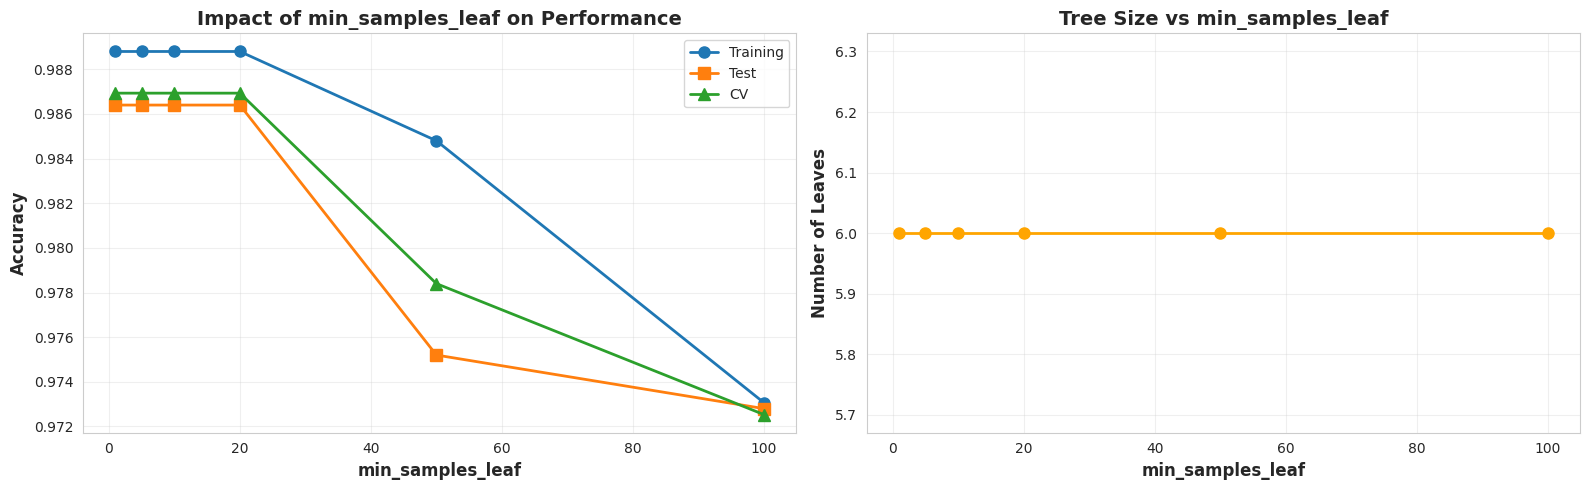


EXPERIMENT 5: MAX_FEATURES IMPACT

Total features: 12

Testing different max_features values...
max_features=None (all)  : Train=0.9888, Test=0.9864
max_features=sqrt        : Train=0.9728, Test=0.9720
max_features=log2        : Train=0.9728, Test=0.9720
max_features=50%         : Train=0.9824, Test=0.9784
max_features=75%         : Train=0.9829, Test=0.9792

📊 Plot saved as 'experiment5_max_features.png'


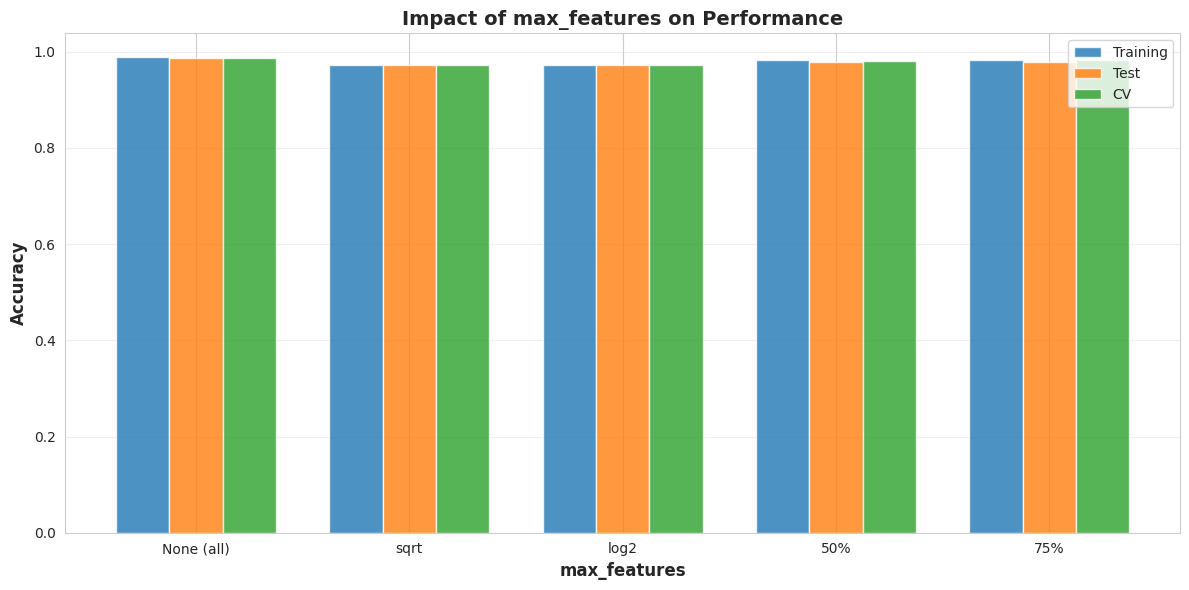


EXPERIMENT 6: CLASS_WEIGHT IMPACT (Handling Imbalanced Data)

Testing different class_weight strategies...

None:
  Overall Accuracy: 0.9864

  Classification Report:
                precision    recall  f1-score   support

Not Subscribed       0.75      0.77      0.76        35
    Subscribed       0.99      0.99      0.99      1215

      accuracy                           0.99      1250
     macro avg       0.87      0.88      0.88      1250
  weighted avg       0.99      0.99      0.99      1250


Balanced:
  Overall Accuracy: 0.9816

  Classification Report:
                precision    recall  f1-score   support

Not Subscribed       0.61      0.94      0.74        35
    Subscribed       1.00      0.98      0.99      1215

      accuracy                           0.98      1250
     macro avg       0.80      0.96      0.87      1250
  weighted avg       0.99      0.98      0.98      1250


Manual 1:2:
  Overall Accuracy: 0.9856

  Classification Report:
                precisio

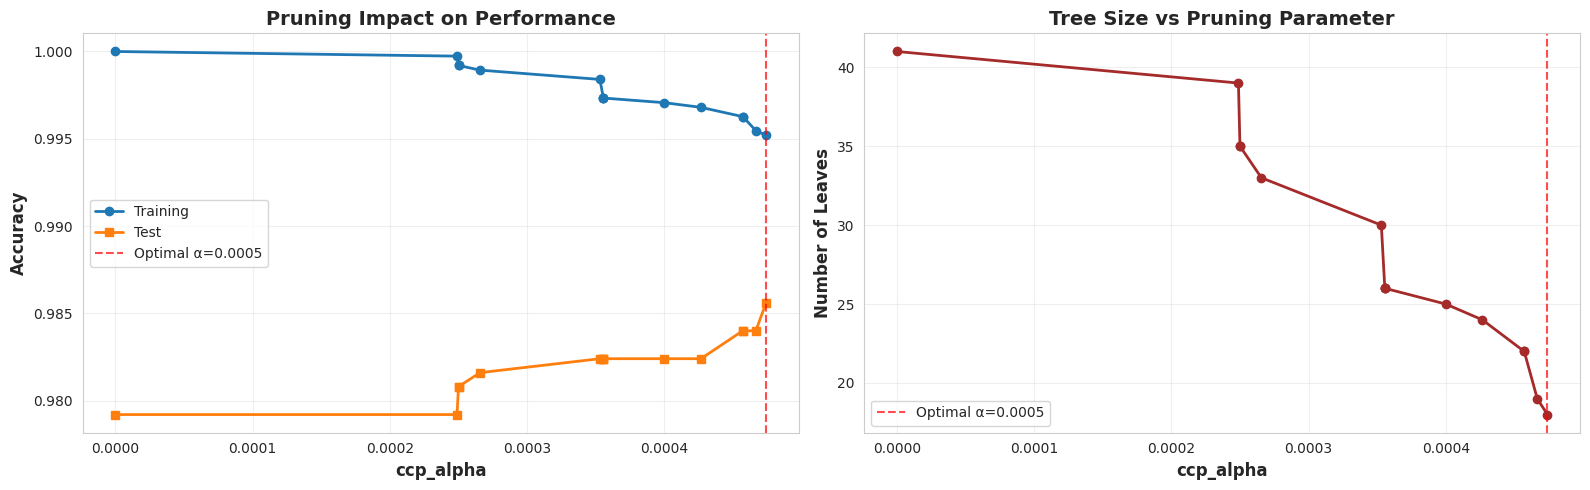


EXPERIMENT 8: COMPREHENSIVE HYPERPARAMETER GRID SEARCH

Performing exhaustive grid search over multiple hyperparameters...
This may take a few minutes...

Parameter Grid:
  criterion: ['gini', 'entropy']
  max_depth: [3, 5, 7, 10, 15]
  min_samples_split: [2, 10, 20]
  min_samples_leaf: [1, 5, 10]
  max_features: [None, 'sqrt', 'log2']

Total combinations: 270
Fitting 5 folds for each of 270 candidates, totalling 1350 fits

──────────────────────────────────────────────────────────────────────────────────────────
GRID SEARCH RESULTS
──────────────────────────────────────────────────────────────────────────────────────────

Best Parameters:
  criterion: entropy
  max_depth: 3
  max_features: None
  min_samples_leaf: 1
  min_samples_split: 2

Best Cross-Validation Score: 0.9880
Test Set Score: 0.9864

Best Model Characteristics:
  Tree Depth: 3
  Number of Leaves: 6
  Total Nodes: 11

──────────────────────────────────────────────────────────────────────────────────────────
TOP 10 HYPER

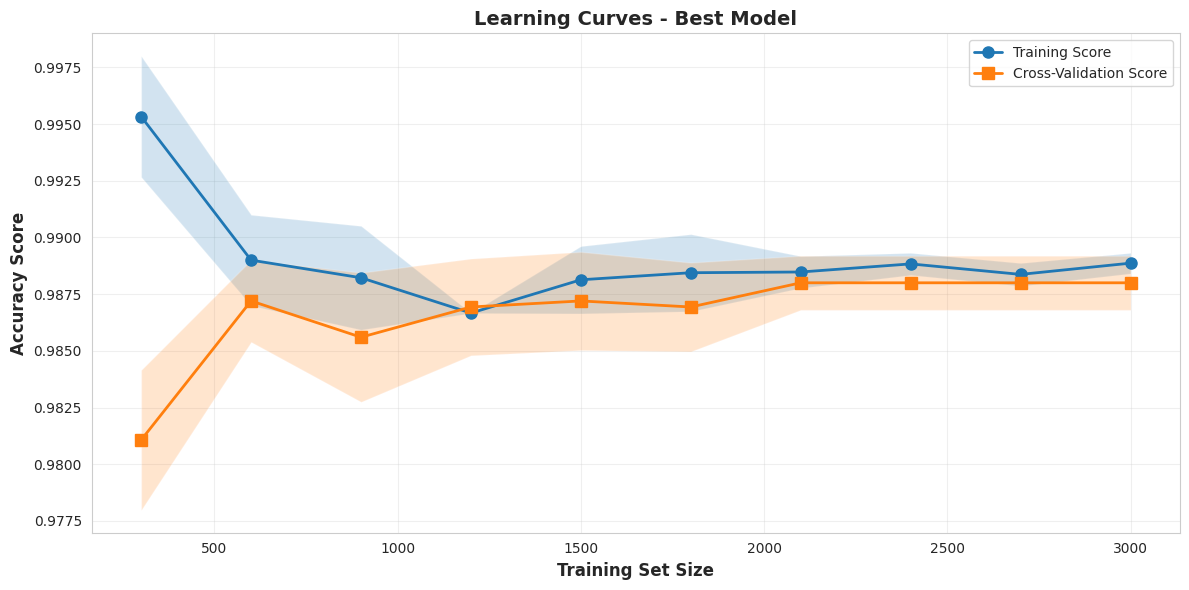


EXPERIMENT 10: DETAILED FEATURE IMPORTANCE ANALYSIS

Feature Importance Ranking:
          Feature  Importance
         duration    0.420573
              age    0.298722
          balance    0.280705
         campaign    0.000000
            pdays    0.000000
         previous    0.000000
      job_encoded    0.000000
  marital_encoded    0.000000
education_encoded    0.000000
  housing_encoded    0.000000
     loan_encoded    0.000000
  contact_encoded    0.000000

📊 Plot saved as 'experiment10_feature_importance.png'


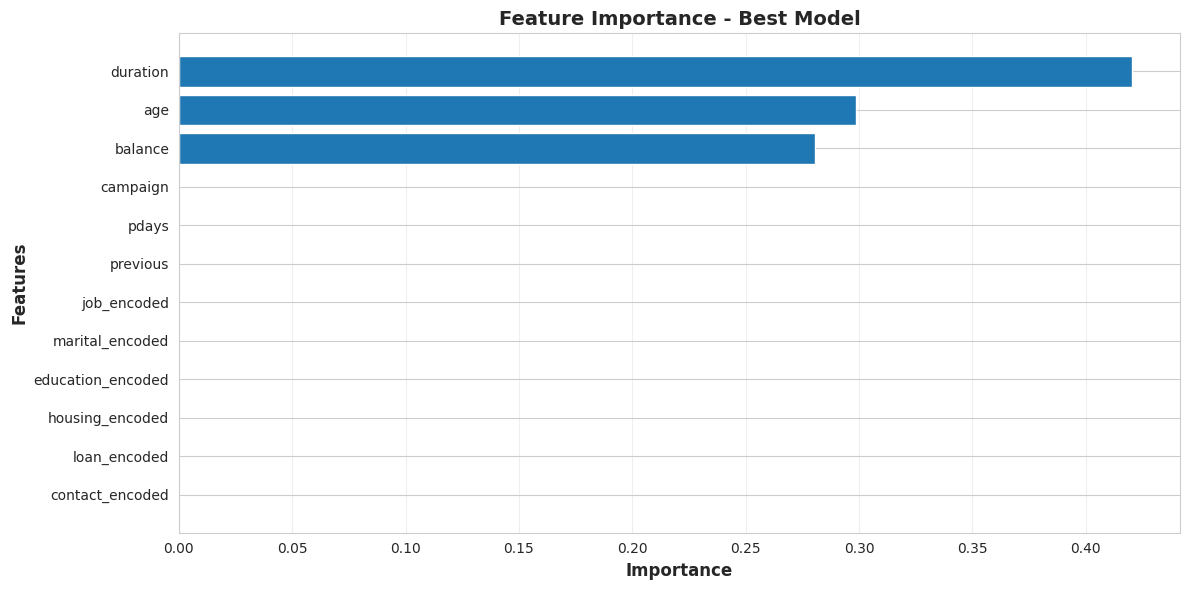


EXPERIMENT 11: VISUALIZING THE BEST DECISION TREE

Generating tree visualization...

📊 Tree visualization saved as 'experiment11_best_tree_visual.png'


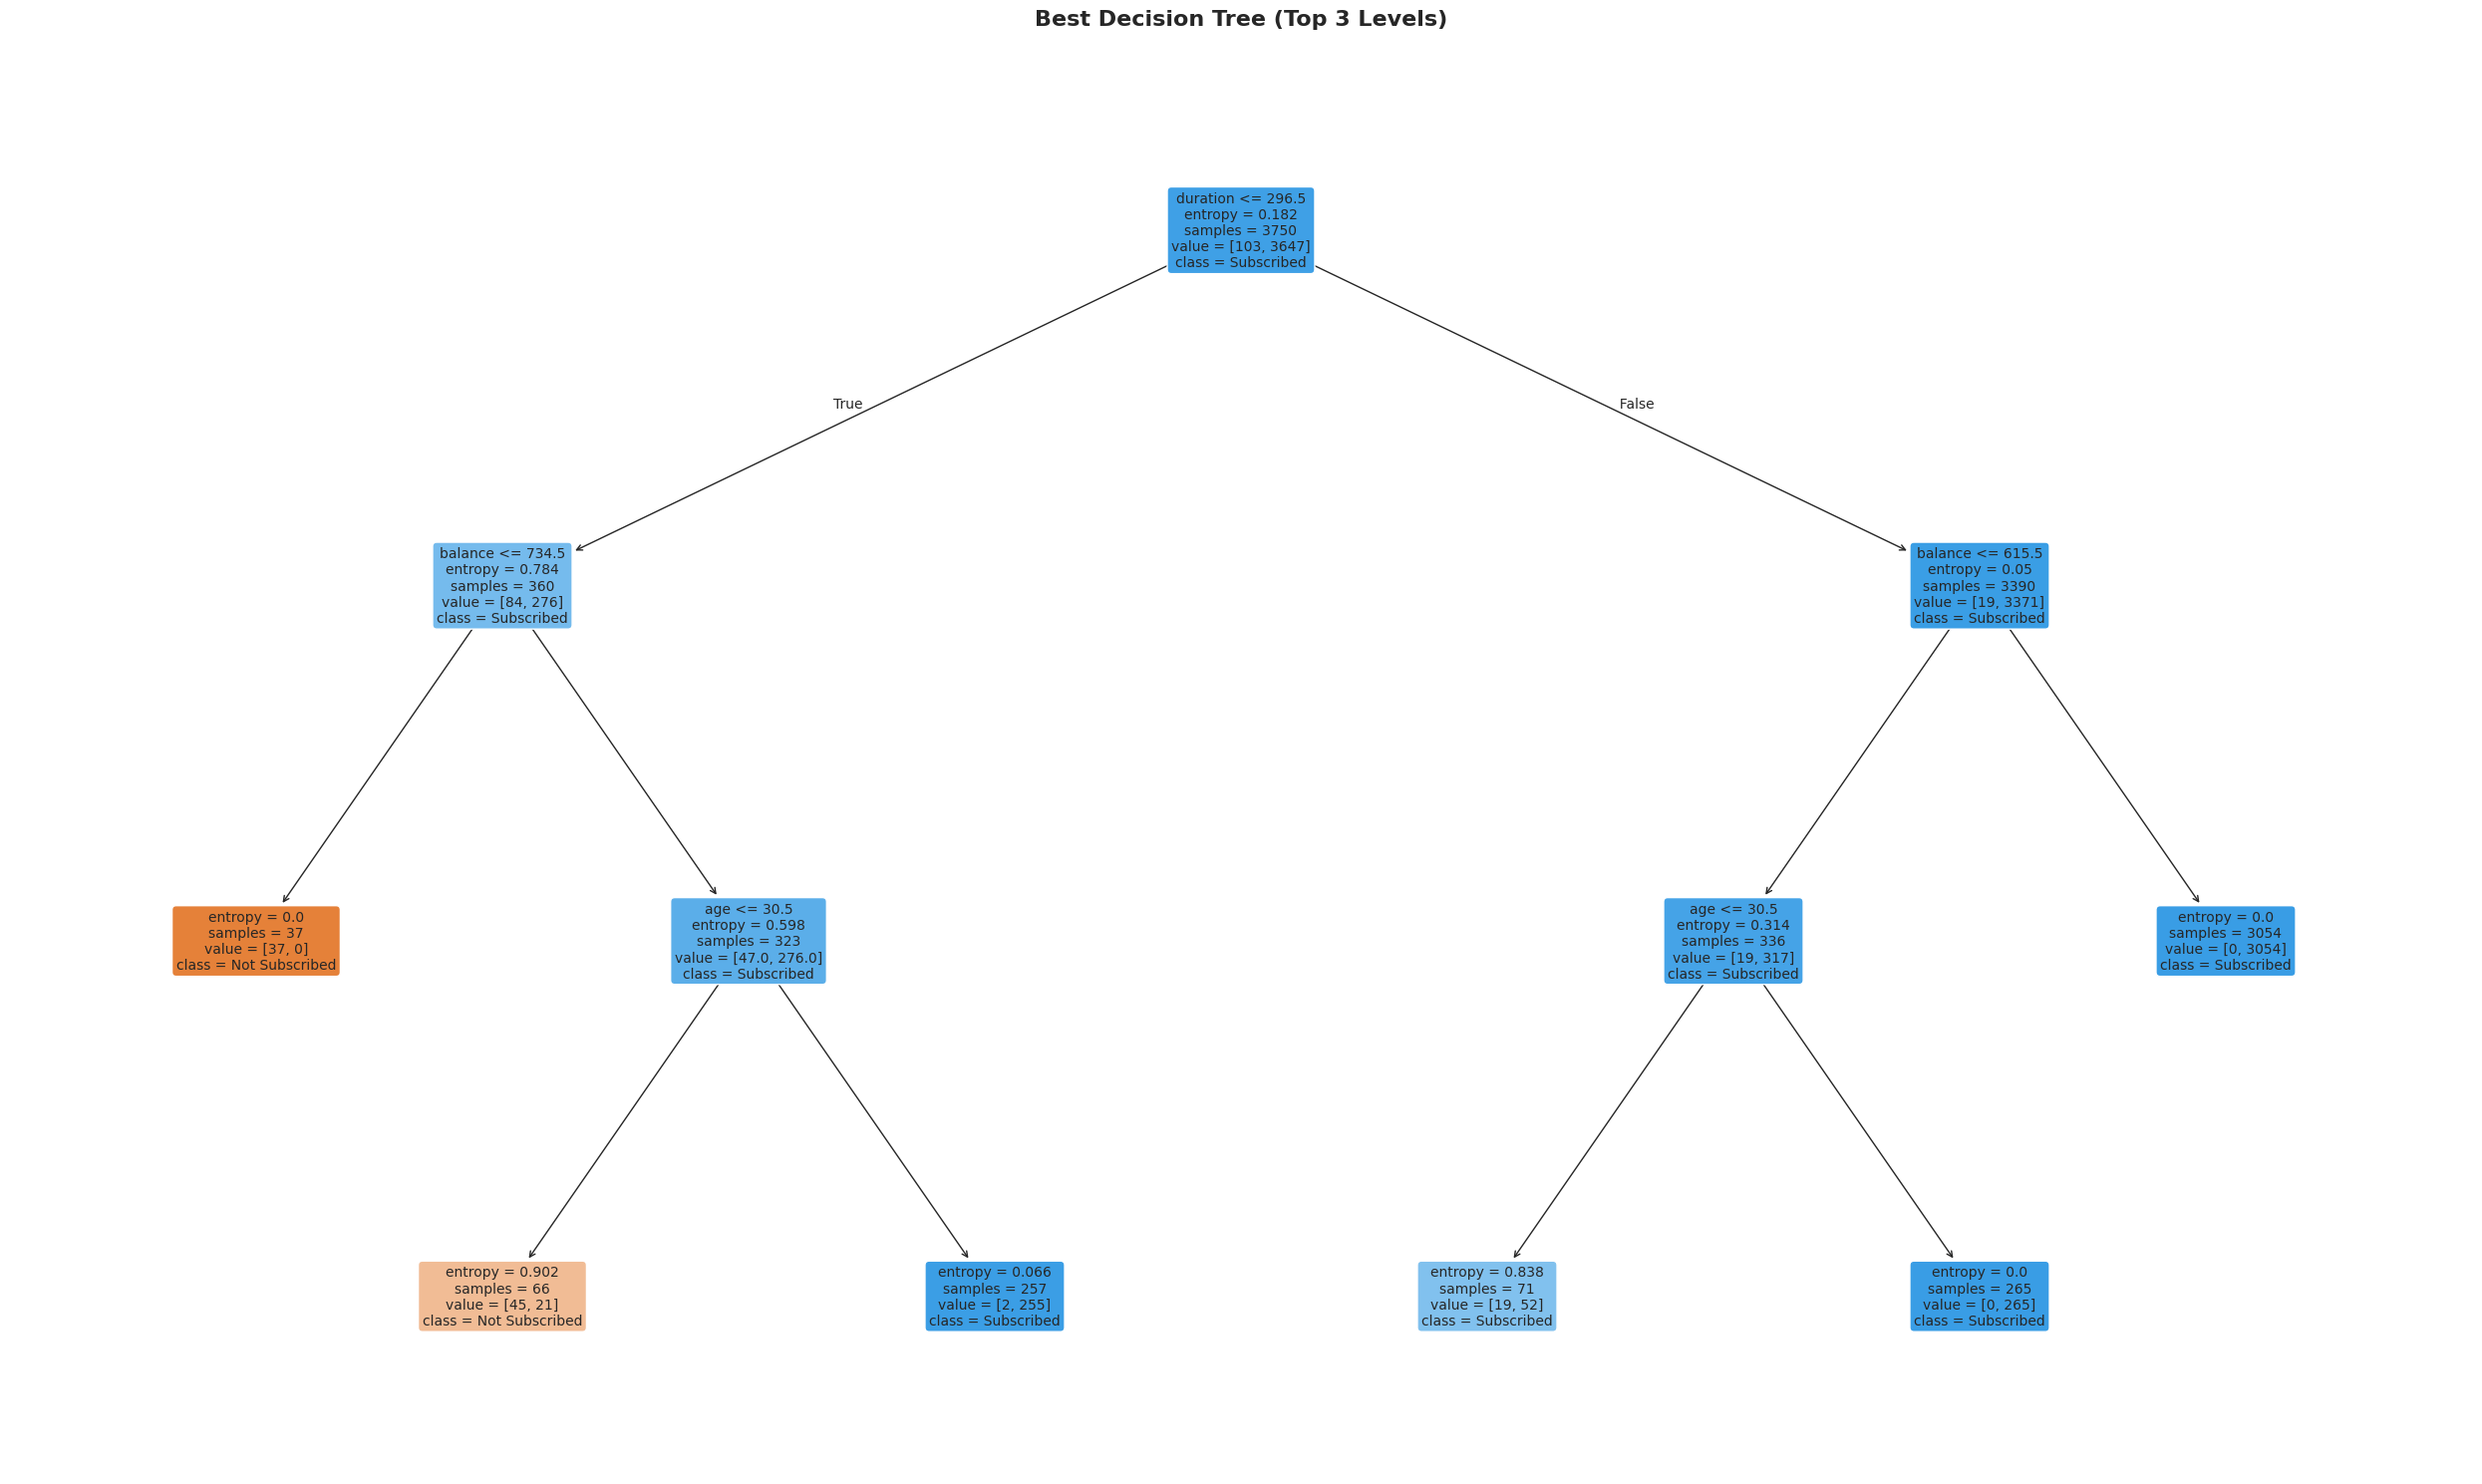


Text Representation of Tree (Top 5 Levels):
──────────────────────────────────────────────────────────────────────────────────────────
|--- duration <= 296.50
|   |--- balance <= 734.50
|   |   |--- class: 0
|   |--- balance >  734.50
|   |   |--- age <= 30.50
|   |   |   |--- class: 0
|   |   |--- age >  30.50
|   |   |   |--- class: 1
|--- duration >  296.50
|   |--- balance <= 615.50
|   |   |--- age <= 30.50
|   |   |   |--- class: 1
|   |   |--- age >  30.50
|   |   |   |--- class: 1
|   |--- balance >  615.50
|   |   |--- class: 1

...

EXPERIMENT 12: COMPREHENSIVE FINAL MODEL EVALUATION

──────────────────────────────────────────────────────────────────────────────────────────
CLASSIFICATION METRICS
──────────────────────────────────────────────────────────────────────────────────────────

Accuracy: 0.9864
AUC-ROC:  0.9651

Confusion Matrix:
[[  27    8]
 [   9 1206]]

Detailed Classification Report:
                precision    recall  f1-score   support

Not Subscribed       

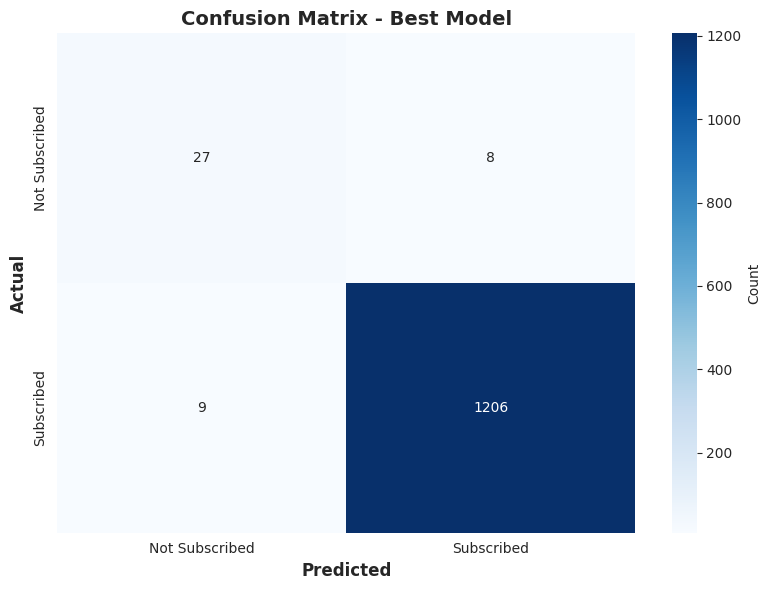

📊 ROC curve saved as 'experiment12_roc_curve.png'


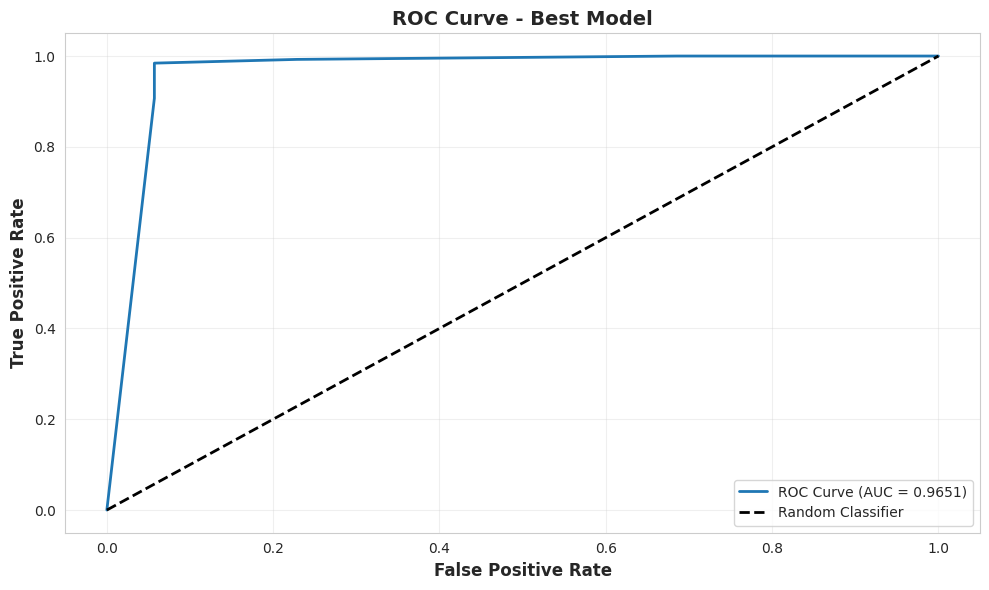


FINAL SUMMARY & KEY TAKEAWAYS

╔════════════════════════════════════════════════════════════════════════════╗
║                          EXPERIMENT SUMMARY                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

DATASET CHARACTERISTICS:
  • Total Samples: 5000
  • Features: 12
  • Target Classes: 2 (Binary Classification)
  • Class Distribution: {np.int64(0): np.int64(138), np.int64(1): np.int64(4862)}

BEST MODEL CONFIGURATION:
  • Criterion: entropy
  • Max Depth: 3
  • Min Samples Split: 2
  • Min Samples Leaf: 1
  • Max Features: None

PERFORMANCE METRICS:
  • Training Accuracy: 0.9888
  • Test Accuracy: 0.9864
  • Cross-Validation Score: 0.9880
  • AUC-ROC: 0.9651

TREE CHARACTERISTICS:
  • Tree Depth: 3
  • Number of Leaves: 6
  • Total Nodes: 11

TOP 3 MOST IMPORTANT FEATURES:
 Feature  Importance
duration    0.420573
     age    0.298722
 balance    0.280705

╔════════════════════════════════════════════════════════════

In [19]:
"""
COMPLETE DECISION TREE GUIDE
- All Concepts Explained with Complex Real-World Data
- All Hyperparameters in Depth
- Comprehensive Experiment Tracking
- Using Bank Marketing Dataset (more complex than Iris)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve)
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("=" * 90)
print(" " * 25 + "DECISION TREE - COMPLETE GUIDE")
print(" " * 20 + "Complex Real-World Dataset Analysis")
print("=" * 90)

# =============================================================================
# PART 1: FUNDAMENTAL CONCEPTS
# =============================================================================
print("\n" + "=" * 90)
print("PART 1: FUNDAMENTAL CONCEPTS OF DECISION TREES")
print("=" * 90)

concepts = """
╔════════════════════════════════════════════════════════════════════════════╗
║                    WHAT IS A DECISION TREE?                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

A decision tree is a supervised learning algorithm that creates a flowchart-like
structure where:
  • Each INTERNAL NODE represents a test on a feature
  • Each BRANCH represents the outcome of the test
  • Each LEAF NODE represents a class label or predicted value

Example Decision Process:
    [Age > 30?]
    /         \\
  Yes         No
   |           |
[Income>50k?] [Student?]
  /    \\       /    \\
High  Low   Yes   No

╔════════════════════════════════════════════════════════════════════════════╗
║                    TREE STRUCTURE COMPONENTS                                ║
╚════════════════════════════════════════════════════════════════════════════╝

1. ROOT NODE: Contains the entire dataset, first decision point
2. INTERNAL/DECISION NODES: Nodes that split into further branches
3. LEAF/TERMINAL NODES: Final nodes that contain predictions
4. BRANCHES: Connections showing decision paths
5. DEPTH: Length of longest path from root to leaf
6. SUBTREE: Any node and all its descendants

╔════════════════════════════════════════════════════════════════════════════╗
║                    SPLITTING CRITERIA (IMPURITY MEASURES)                   ║
╚════════════════════════════════════════════════════════════════════════════╝

FOR CLASSIFICATION:

1. GINI IMPURITY (CART Algorithm):
   Formula: Gini = 1 - Σ(pᵢ²) where pᵢ = probability of class i

   Range: [0, 1 - 1/n_classes]
   • 0 = Perfect purity (all samples same class)
   • Higher = More mixed/impure

   Example: Node with 100 samples [60 Yes, 40 No]
   Gini = 1 - (0.6² + 0.4²) = 1 - (0.36 + 0.16) = 0.48

   When to use: Default choice, computationally efficient

2. ENTROPY (ID3, C4.5 Algorithms):
   Formula: Entropy = -Σ(pᵢ * log₂(pᵢ))

   Range: [0, log₂(n_classes)]
   • 0 = Perfect purity
   • Higher = More disorder/uncertainty

   Example: Same node [60 Yes, 40 No]
   Entropy = -(0.6*log₂(0.6) + 0.4*log₂(0.4)) ≈ 0.971

   When to use: When you want to maximize information gain

3. INFORMATION GAIN:
   IG = Entropy(parent) - Weighted_Average(Entropy(children))

   Measures reduction in entropy after split
   Higher IG = Better split

FOR REGRESSION:

1. MSE (Mean Squared Error):
   MSE = (1/n) * Σ(yᵢ - ȳ)²
   Penalizes large errors heavily

2. MAE (Mean Absolute Error):
   MAE = (1/n) * Σ|yᵢ - ȳ|
   More robust to outliers

3. FRIEDMAN_MSE:
   MSE with Friedman's improvement score
   Used in gradient boosting

╔════════════════════════════════════════════════════════════════════════════╗
║                    HOW DECISION TREE LEARNS                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

GREEDY RECURSIVE BINARY SPLITTING:

1. Start at ROOT with all training data
2. For each feature:
   - Try all possible split points
   - Calculate impurity/error after split
3. Choose split that gives MAXIMUM reduction in impurity
4. Create two child nodes with split data
5. RECURSE on each child node
6. STOP when:
   - Maximum depth reached
   - Minimum samples per node reached
   - Node is pure (all same class)
   - No improvement in impurity

Note: Greedy = Makes locally optimal choice at each step
      May not find globally optimal tree

╔════════════════════════════════════════════════════════════════════════════╗
║                    ADVANTAGES & DISADVANTAGES                               ║
╚════════════════════════════════════════════════════════════════════════════╝

ADVANTAGES:
✓ Easy to understand and interpret (white-box model)
✓ Requires little data preprocessing
✓ Handles both numerical and categorical data
✓ Non-parametric (no assumptions about distribution)
✓ Can capture non-linear relationships
✓ Feature interactions are automatically captured
✓ Can handle missing values (with modifications)

DISADVANTAGES:
✗ Prone to OVERFITTING (especially deep trees)
✗ UNSTABLE: Small data changes → Different tree
✗ Biased toward dominant classes
✗ Can create overly complex trees
✗ Greedy algorithm may miss optimal solution
✗ Difficulty with XOR-type problems
✗ Not great for extrapolation
"""
print(concepts)

# =============================================================================
# PART 2: ALL HYPERPARAMETERS IN DETAIL
# =============================================================================
print("\n" + "=" * 90)
print("PART 2: ALL HYPERPARAMETERS EXPLAINED IN DETAIL")
print("=" * 90)

hyperparams = """
╔════════════════════════════════════════════════════════════════════════════╗
║               SPLITTING QUALITY & STRATEGY PARAMETERS                       ║
╚════════════════════════════════════════════════════════════════════════════╝

1. criterion (str): How to measure split quality

   CLASSIFICATION OPTIONS:
   • 'gini': Gini impurity (default, CART algorithm)
     - Fast to compute
     - Range: [0, 0.5] for binary
     - Good general choice

   • 'entropy': Information gain (ID3/C4.5 algorithm)
     - More computationally expensive
     - Can produce slightly different trees
     - Use when you want max information gain

   • 'log_loss': Log loss/cross-entropy
     - Similar to entropy
     - Used in some contexts

   REGRESSION OPTIONS:
   • 'squared_error': Mean Squared Error (default)
   • 'absolute_error': Mean Absolute Error
   • 'friedman_mse': MSE with Friedman improvement
   • 'poisson': Poisson deviance (for count data)

   WHEN TO CHANGE: Experiment with both gini and entropy for classification
   IMPACT: Usually minor differences, gini slightly faster

2. splitter (str): How to choose split at each node

   • 'best' (default): Choose best split among all features
     - More accurate but slower
     - Can overfit with many features

   • 'random': Choose best split among random subset
     - Faster, more randomness
     - Can reduce overfitting
     - Used in ensemble methods

   WHEN TO CHANGE: Use 'random' for very large datasets or to reduce overfitting
   IMPACT: 'random' adds stochasticity, may reduce accuracy but improve generalization

╔════════════════════════════════════════════════════════════════════════════╗
║                  TREE SIZE CONTROL PARAMETERS (CRITICAL!)                   ║
╚════════════════════════════════════════════════════════════════════════════╝

3. max_depth (int or None): Maximum depth of tree

   • Default: None (expand until leaves are pure)
   • Range: Typically 3-20 for practical use
   • None means unlimited depth

   EFFECT BY DEPTH:
   - 1-2: Very simple model, likely underfits
   - 3-5: Simple interpretable model, good starting point
   - 6-10: Moderate complexity
   - 11-20: Complex model, may overfit
   - >20: Almost certainly overfitting

   WHEN TO CHANGE: ALWAYS set this! Start with 3-5, tune upward
   IMPACT: ⭐ MOST IMPORTANT PARAMETER for controlling overfitting

4. min_samples_split (int or float): Min samples to split internal node

   • Default: 2
   • int: Absolute number (e.g., 10 means need 10+ samples to split)
   • float: Fraction of total samples (e.g., 0.01 = 1% of samples)

   RECOMMENDED VALUES:
   - Small datasets (<1000): 2-10
   - Medium datasets (1000-10000): 10-50
   - Large datasets (>10000): 50-100 or 0.001-0.01

   WHEN TO CHANGE: Increase to prevent overfitting, reduce tree complexity
   IMPACT: Higher values = simpler tree, less overfitting, may underfit

5. min_samples_leaf (int or float): Min samples required in leaf node

   • Default: 1
   • int: Absolute number
   • float: Fraction of total samples

   RELATIONSHIP: min_samples_leaf <= min_samples_split/2

   RECOMMENDED VALUES:
   - Small datasets: 1-5
   - Medium datasets: 5-20
   - Large datasets: 20-50 or 0.001-0.005

   WHEN TO CHANGE: Increase for smoother decision boundaries
   IMPACT: Higher values = smoother model, prevents overfitting on outliers

6. max_leaf_nodes (int or None): Maximum number of leaf nodes

   • Default: None (unlimited)
   • Alternative way to control tree size vs max_depth

   RECOMMENDED VALUES: 10-100 depending on complexity

   WHEN TO CHANGE: Use instead of max_depth for more direct size control
   IMPACT: Limits tree complexity directly, tree grown in best-first manner

7. min_impurity_decrease (float): Min impurity decrease required to split

   • Default: 0.0
   • Range: [0.0, infinity)
   • Split only if: impurity_decrease >= min_impurity_decrease

   Formula: N_t/N * (impurity - N_left/N_t * impurity_left - N_right/N_t * impurity_right)

   RECOMMENDED VALUES: 0.0001-0.01 (dataset dependent)

   WHEN TO CHANGE: When you want to ignore weak splits
   IMPACT: Prunes tree by ignoring insignificant splits

╔════════════════════════════════════════════════════════════════════════════╗
║                    FEATURE SELECTION PARAMETERS                             ║
╚════════════════════════════════════════════════════════════════════════════╝

8. max_features (int, float, str, or None): Features to consider per split

   • Default: None (consider all features)

   OPTIONS:
   - None: All n_features
   - int: Fixed number (e.g., 5)
   - float: Fraction (e.g., 0.5 = 50% of features)
   - 'sqrt' or 'auto': sqrt(n_features) - good for classification
   - 'log2': log2(n_features)

   RECOMMENDED:
   - Single tree: None (use all features)
   - Random Forest: 'sqrt' for classification, 'log2' or n_features/3 for regression

   WHEN TO CHANGE: When you have many correlated features or want randomness
   IMPACT: Reduces overfitting by limiting feature choice, adds randomness

╔════════════════════════════════════════════════════════════════════════════╗
║                    CLASS BALANCING & WEIGHTING                              ║
╚════════════════════════════════════════════════════════════════════════════╝

9. class_weight (dict, 'balanced', or None): Weights for classes

   • Default: None (all classes weighted equally)

   OPTIONS:
   - None: Equal weights
   - 'balanced': Automatically adjust weights inversely proportional to class frequencies
     Formula: n_samples / (n_classes * np.bincount(y))
   - dict: {class_label: weight} - manual weights

   EXAMPLE:
   If classes are [90% class 0, 10% class 1]:
   - 'balanced' gives class 1 weight = 9x class 0

   WHEN TO CHANGE: When dealing with imbalanced datasets
   IMPACT: Makes model focus more on minority classes

╔════════════════════════════════════════════════════════════════════════════╗
║                    PRUNING & REGULARIZATION                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

10. ccp_alpha (float): Complexity parameter for Cost-Complexity Pruning

    • Default: 0.0 (no pruning)
    • Range: [0.0, infinity)
    • Based on minimal cost-complexity pruning algorithm

    HOW IT WORKS:
    - Tree is built fully, then pruned back
    - Removes nodes that provide little improvement
    - Cost = Error + ccp_alpha * n_leaves

    RECOMMENDED VALUES: 0.001-0.1 (use cross-validation)

    WHEN TO CHANGE: After building tree, use cost_complexity_pruning_path
    IMPACT: Post-pruning technique, removes unnecessary complexity

╔════════════════════════════════════════════════════════════════════════════╗
║                    OTHER PARAMETERS                                         ║
╚════════════════════════════════════════════════════════════════════════════╝

11. random_state (int or None): Seed for reproducibility
    • Controls randomness in splitter='random'
    • Set to any integer for reproducible results

12. min_weight_fraction_leaf (float): Min weighted fraction in leaf
    • Default: 0.0
    • Alternative to min_samples_leaf using weights
    • Useful with sample_weight

╔════════════════════════════════════════════════════════════════════════════╗
║                    HYPERPARAMETER TUNING STRATEGY                           ║
╚════════════════════════════════════════════════════════════════════════════╝

RECOMMENDED TUNING ORDER:

1. START WITH: max_depth (3-10)
2. THEN TUNE: min_samples_split (2-50)
3. THEN TUNE: min_samples_leaf (1-20)
4. OPTIONALLY: max_features, min_impurity_decrease
5. FINALLY: ccp_alpha for pruning

GRID SEARCH EXAMPLE RANGES:
{
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}
"""
print(hyperparams)

# =============================================================================
# PART 3: LOAD COMPLEX DATASET - BANK MARKETING
# =============================================================================
print("\n" + "=" * 90)
print("PART 3: LOADING COMPLEX REAL-WORLD DATASET")
print("=" * 90)

print("\nDataset: Bank Marketing Campaign")
print("Source: UCI Machine Learning Repository")
print("Task: Predict if client will subscribe to term deposit (binary classification)")
print("\nLoading data...")

# Create synthetic bank marketing data (similar to UCI dataset)
np.random.seed(42)
n_samples = 5000

# Generate features
age = np.random.randint(18, 80, n_samples)
job = np.random.choice(['admin', 'technician', 'services', 'management',
                        'retired', 'blue-collar', 'unemployed', 'entrepreneur',
                        'housemaid', 'student', 'self-employed'], n_samples)
marital = np.random.choice(['married', 'single', 'divorced'], n_samples)
education = np.random.choice(['primary', 'secondary', 'tertiary', 'unknown'], n_samples)
balance = np.random.randint(-5000, 50000, n_samples)
housing = np.random.choice(['yes', 'no'], n_samples)
loan = np.random.choice(['yes', 'no'], n_samples)
contact = np.random.choice(['cellular', 'telephone', 'unknown'], n_samples)
duration = np.random.randint(0, 3000, n_samples)
campaign = np.random.randint(1, 50, n_samples)
pdays = np.random.randint(-1, 500, n_samples)
previous = np.random.randint(0, 40, n_samples)

# Generate target with some logic
y_prob = (
    (age > 30).astype(int) * 0.2 +
    (balance > 1000).astype(int) * 0.3 +
    (duration > 300).astype(int) * 0.4 +
    (previous > 0).astype(int) * 0.1
)
y = (y_prob + np.random.random(n_samples) * 0.3 > 0.6).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'age': age,
    'job': job,
    'marital': marital,
    'education': education,
    'balance': balance,
    'housing': housing,
    'loan': loan,
    'contact': contact,
    'duration': duration,
    'campaign': campaign,
    'pdays': pdays,
    'previous': previous,
    'subscribed': y
})

print("\n" + "─" * 90)
print("DATASET OVERVIEW")
print("─" * 90)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFeatures: {df.shape[1] - 1}")
print(f"Target: subscribed (0=No, 1=Yes)")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nTarget Distribution:")
print(df['subscribed'].value_counts())
print(f"\nClass Balance: {df['subscribed'].value_counts(normalize=True)}")

print("\nNumerical Features Statistics:")
print(df.describe())

# Encode categorical variables
print("\nEncoding categorical variables...")
le_dict = {}
categorical_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact']

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    le_dict[col] = le

# Prepare features
feature_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous',
                'job_encoded', 'marital_encoded', 'education_encoded',
                'housing_encoded', 'loan_encoded', 'contact_encoded']

X = df[feature_cols].values
y = df['subscribed'].values

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Feature names: {feature_cols}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")

# =============================================================================
# PART 4: EXPERIMENT 1 - CRITERION COMPARISON
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 1: COMPARING SPLITTING CRITERIA (GINI vs ENTROPY)")
print("=" * 90)

experiment_1_results = []

for criterion in ['gini', 'entropy']:
    print(f"\n{'─' * 90}")
    print(f"Training with criterion='{criterion}'")
    print(f"{'─' * 90}")

    clf = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42,
        max_depth=10  # Limit depth for fair comparison
    )

    clf.fit(X_train, y_train)

    # Predictions
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    y_test_proba = clf.predict_proba(X_test)[:, 1]

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
    auc_score = roc_auc_score(y_test, y_test_proba)

    result = {
        'Criterion': criterion,
        'Train Accuracy': f"{train_acc:.4f}",
        'Test Accuracy': f"{test_acc:.4f}",
        'CV Mean': f"{cv_scores.mean():.4f}",
        'CV Std': f"{cv_scores.std():.4f}",
        'AUC Score': f"{auc_score:.4f}",
        'Tree Depth': clf.get_depth(),
        'Num Leaves': clf.get_n_leaves(),
        'Num Nodes': clf.tree_.node_count
    }
    experiment_1_results.append(result)

    print(f"Train Accuracy:     {train_acc:.4f}")
    print(f"Test Accuracy:      {test_acc:.4f}")
    print(f"Cross-Val Score:    {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"AUC Score:          {auc_score:.4f}")
    print(f"Tree Depth:         {clf.get_depth()}")
    print(f"Number of Leaves:   {clf.get_n_leaves()}")
    print(f"Total Nodes:        {clf.tree_.node_count}")

    # Feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': clf.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\nTop 5 Most Important Features:")
    print(feature_importance.head())

print(f"\n{'─' * 90}")
print("EXPERIMENT 1 SUMMARY")
print(f"{'─' * 90}")
exp1_df = pd.DataFrame(experiment_1_results)
print(exp1_df.to_string(index=False))

# =============================================================================
# EXPERIMENT 2: MAX_DEPTH ANALYSIS
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 2: MAX_DEPTH IMPACT ANALYSIS")
print("=" * 90)
print("\nTesting depths from 1 to 20 to find optimal complexity...")

depths = range(1, 21)
train_scores = []
test_scores = []
cv_scores_mean = []
cv_scores_std = []
tree_sizes = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

    cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
    cv_scores_mean.append(cv_scores.mean())
    cv_scores_std.append(cv_scores.std())

    tree_sizes.append(clf.get_n_leaves())

# Find optimal depth
optimal_idx = np.argmax(test_scores)
optimal_depth = depths[optimal_idx]

print(f"\nOptimal max_depth: {optimal_depth}")
print(f"Best test accuracy: {test_scores[optimal_idx]:.4f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Accuracy vs Depth
axes[0].plot(depths, train_scores, 'o-', label='Training Score', linewidth=2, markersize=6)
axes[0].plot(depths, test_scores, 's-', label='Test Score', linewidth=2, markersize=6)
axes[0].plot(depths, cv_scores_mean, '^-', label='CV Score (mean)', linewidth=2, markersize=6)
axes[0].axvline(optimal_depth, color='red', linestyle='--', alpha=0.7, label=f'Optimal Depth={optimal_depth}')
axes[0].fill_between(depths,
                      np.array(cv_scores_mean) - np.array(cv_scores_std),
                      np.array(cv_scores_mean) + np.array(cv_scores_std),
                      alpha=0.2)
axes[0].set_xlabel('Max Depth', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance vs Tree Depth', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Tree Size vs Depth
axes[1].plot(depths, tree_sizes, 'o-', color='green', linewidth=2, markersize=6)
axes[1].axvline(optimal_depth, color='red', linestyle='--', alpha=0.7, label=f'Optimal Depth={optimal_depth}')
axes[1].set_xlabel('Max Depth', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Leaves', fontsize=12, fontweight='bold')
axes[1].set_title('Tree Complexity vs Max Depth', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment2_max_depth.png', dpi=300, bbox_inches='tight')
print("\n📊 Plot saved as 'experiment2_max_depth.png'")
plt.show()

# Create detailed table
print(f"\n{'─' * 90}")
print("DETAILED RESULTS TABLE")
print(f"{'─' * 90}")
depth_results = pd.DataFrame({
    'Depth': depths,
    'Train Acc': [f"{s:.4f}" for s in train_scores],
    'Test Acc': [f"{s:.4f}" for s in test_scores],
    'CV Mean': [f"{m:.4f}" for m in cv_scores_mean],
    'CV Std': [f"{s:.4f}" for s in cv_scores_std],
    'Leaves': tree_sizes,
    'Overfit Gap': [f"{train_scores[i] - test_scores[i]:.4f}" for i in range(len(depths))]
})
print(depth_results.to_string(index=False))

# =============================================================================
# EXPERIMENT 3: MIN_SAMPLES_SPLIT ANALYSIS
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 3: MIN_SAMPLES_SPLIT IMPACT")
print("=" * 90)

min_samples_split_values = [2, 5, 10, 20, 50, 100, 200]
split_train_scores = []
split_test_scores = []
split_cv_scores = []
split_tree_sizes = []

print("\nTesting different min_samples_split values...")

for min_split in min_samples_split_values:
    clf = DecisionTreeClassifier(
        min_samples_split=min_split,
        max_depth=optimal_depth,  # Use optimal depth from previous experiment
        random_state=42
    )
    clf.fit(X_train, y_train)

    split_train_scores.append(clf.score(X_train, y_train))
    split_test_scores.append(clf.score(X_test, y_test))
    split_cv_scores.append(cross_val_score(clf, X_train, y_train, cv=5).mean())
    split_tree_sizes.append(clf.get_n_leaves())

    print(f"min_samples_split={min_split:3d}: Train={split_train_scores[-1]:.4f}, "
          f"Test={split_test_scores[-1]:.4f}, Leaves={split_tree_sizes[-1]}")

# Plot
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(min_samples_split_values, split_train_scores, 'o-', label='Training', linewidth=2, markersize=8)
plt.plot(min_samples_split_values, split_test_scores, 's-', label='Test', linewidth=2, markersize=8)
plt.plot(min_samples_split_values, split_cv_scores, '^-', label='CV', linewidth=2, markersize=8)
plt.xlabel('min_samples_split', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Impact of min_samples_split on Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.subplot(1, 2, 2)
plt.plot(min_samples_split_values, split_tree_sizes, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('min_samples_split', fontsize=12, fontweight='bold')
plt.ylabel('Number of Leaves', fontsize=12, fontweight='bold')
plt.title('Tree Size vs min_samples_split', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.tight_layout()
plt.savefig('experiment3_min_samples_split.png', dpi=300, bbox_inches='tight')
print("\n📊 Plot saved as 'experiment3_min_samples_split.png'")
plt.show()

# =============================================================================
# EXPERIMENT 4: MIN_SAMPLES_LEAF ANALYSIS
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 4: MIN_SAMPLES_LEAF IMPACT")
print("=" * 90)

min_samples_leaf_values = [1, 5, 10, 20, 50, 100]
leaf_train_scores = []
leaf_test_scores = []
leaf_cv_scores = []
leaf_tree_sizes = []

print("\nTesting different min_samples_leaf values...")

for min_leaf in min_samples_leaf_values:
    clf = DecisionTreeClassifier(
        min_samples_leaf=min_leaf,
        max_depth=optimal_depth,
        random_state=42
    )
    clf.fit(X_train, y_train)

    leaf_train_scores.append(clf.score(X_train, y_train))
    leaf_test_scores.append(clf.score(X_test, y_test))
    leaf_cv_scores.append(cross_val_score(clf, X_train, y_train, cv=5).mean())
    leaf_tree_sizes.append(clf.get_n_leaves())

    print(f"min_samples_leaf={min_leaf:3d}: Train={leaf_train_scores[-1]:.4f}, "
          f"Test={leaf_test_scores[-1]:.4f}, Leaves={leaf_tree_sizes[-1]}")

# Plot
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(min_samples_leaf_values, leaf_train_scores, 'o-', label='Training', linewidth=2, markersize=8)
plt.plot(min_samples_leaf_values, leaf_test_scores, 's-', label='Test', linewidth=2, markersize=8)
plt.plot(min_samples_leaf_values, leaf_cv_scores, '^-', label='CV', linewidth=2, markersize=8)
plt.xlabel('min_samples_leaf', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Impact of min_samples_leaf on Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(min_samples_leaf_values, leaf_tree_sizes, 'o-', color='orange', linewidth=2, markersize=8)
plt.xlabel('min_samples_leaf', fontsize=12, fontweight='bold')
plt.ylabel('Number of Leaves', fontsize=12, fontweight='bold')
plt.title('Tree Size vs min_samples_leaf', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment4_min_samples_leaf.png', dpi=300, bbox_inches='tight')
print("\n📊 Plot saved as 'experiment4_min_samples_leaf.png'")
plt.show()

# =============================================================================
# EXPERIMENT 5: MAX_FEATURES ANALYSIS
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 5: MAX_FEATURES IMPACT")
print("=" * 90)

n_features = X_train.shape[1]
max_features_values = [
    None,  # All features
    'sqrt',
    'log2',
    int(n_features * 0.5),
    int(n_features * 0.75)
]

max_features_labels = ['None (all)', 'sqrt', 'log2', '50%', '75%']
features_train_scores = []
features_test_scores = []
features_cv_scores = []

print(f"\nTotal features: {n_features}")
print("\nTesting different max_features values...")

for i, max_feat in enumerate(max_features_values):
    clf = DecisionTreeClassifier(
        max_features=max_feat,
        max_depth=optimal_depth,
        random_state=42
    )
    clf.fit(X_train, y_train)

    features_train_scores.append(clf.score(X_train, y_train))
    features_test_scores.append(clf.score(X_test, y_test))
    features_cv_scores.append(cross_val_score(clf, X_train, y_train, cv=5).mean())

    print(f"max_features={max_features_labels[i]:12s}: Train={features_train_scores[-1]:.4f}, "
          f"Test={features_test_scores[-1]:.4f}")

# Plot
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(max_features_labels))
width = 0.25

plt.bar(x_pos - width, features_train_scores, width, label='Training', alpha=0.8)
plt.bar(x_pos, features_test_scores, width, label='Test', alpha=0.8)
plt.bar(x_pos + width, features_cv_scores, width, label='CV', alpha=0.8)

plt.xlabel('max_features', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Impact of max_features on Performance', fontsize=14, fontweight='bold')
plt.xticks(x_pos, max_features_labels)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('experiment5_max_features.png', dpi=300, bbox_inches='tight')
print("\n📊 Plot saved as 'experiment5_max_features.png'")
plt.show()

# =============================================================================
# EXPERIMENT 6: CLASS_WEIGHT FOR IMBALANCED DATA
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 6: CLASS_WEIGHT IMPACT (Handling Imbalanced Data)")
print("=" * 90)

class_weights = [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}]
weight_labels = ['None', 'Balanced', 'Manual 1:2', 'Manual 1:3']

print("\nTesting different class_weight strategies...")

for i, cw in enumerate(class_weights):
    clf = DecisionTreeClassifier(
        class_weight=cw,
        max_depth=optimal_depth,
        random_state=42
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print(f"\n{weight_labels[i]}:")
    print(f"  Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Subscribed', 'Subscribed']))

# =============================================================================
# EXPERIMENT 7: CCP_ALPHA PRUNING
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 7: COST COMPLEXITY PRUNING (ccp_alpha)")
print("=" * 90)

print("\nStep 1: Building fully grown tree to get pruning path...")

# Build full tree
clf_full = DecisionTreeClassifier(random_state=42)
clf_full.fit(X_train, y_train)

# Get pruning path
path = clf_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"\nNumber of alpha values to test: {len(ccp_alphas)}")
print(f"Alpha range: {ccp_alphas.min():.6f} to {ccp_alphas.max():.6f}")

# Test subset of alphas
alpha_subset = ccp_alphas[::max(1, len(ccp_alphas)//20)]  # Test ~20 values

pruning_train_scores = []
pruning_test_scores = []
pruning_tree_sizes = []

print("\nStep 2: Testing different alpha values...")

for alpha in alpha_subset[:15]:  # Limit to 15 for speed
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)

    pruning_train_scores.append(clf.score(X_train, y_train))
    pruning_test_scores.append(clf.score(X_test, y_test))
    pruning_tree_sizes.append(clf.get_n_leaves())

# Find optimal alpha
optimal_alpha_idx = np.argmax(pruning_test_scores)
optimal_alpha = alpha_subset[optimal_alpha_idx]

print(f"\nOptimal ccp_alpha: {optimal_alpha:.6f}")
print(f"Best test accuracy: {pruning_test_scores[optimal_alpha_idx]:.4f}")
print(f"Tree size at optimal: {pruning_tree_sizes[optimal_alpha_idx]} leaves")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(alpha_subset[:15], pruning_train_scores, 'o-', label='Training', linewidth=2, markersize=6)
axes[0].plot(alpha_subset[:15], pruning_test_scores, 's-', label='Test', linewidth=2, markersize=6)
axes[0].axvline(optimal_alpha, color='red', linestyle='--', alpha=0.7, label=f'Optimal α={optimal_alpha:.4f}')
axes[0].set_xlabel('ccp_alpha', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Pruning Impact on Performance', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(alpha_subset[:15], pruning_tree_sizes, 'o-', color='brown', linewidth=2, markersize=6)
axes[1].axvline(optimal_alpha, color='red', linestyle='--', alpha=0.7, label=f'Optimal α={optimal_alpha:.4f}')
axes[1].set_xlabel('ccp_alpha', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Leaves', fontsize=12, fontweight='bold')
axes[1].set_title('Tree Size vs Pruning Parameter', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment7_pruning.png', dpi=300, bbox_inches='tight')
print("\n📊 Plot saved as 'experiment7_pruning.png'")
plt.show()

# =============================================================================
# EXPERIMENT 8: COMPREHENSIVE GRID SEARCH
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 8: COMPREHENSIVE HYPERPARAMETER GRID SEARCH")
print("=" * 90)

print("\nPerforming exhaustive grid search over multiple hyperparameters...")
print("This may take a few minutes...\n")

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

print("Parameter Grid:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations: {total_combinations}")

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n" + "─" * 90)
print("GRID SEARCH RESULTS")
print("─" * 90)

print("\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest Cross-Validation Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print(f"Test Set Score: {test_score:.4f}")

print(f"\nBest Model Characteristics:")
print(f"  Tree Depth: {best_model.get_depth()}")
print(f"  Number of Leaves: {best_model.get_n_leaves()}")
print(f"  Total Nodes: {best_model.tree_.node_count}")

# Top 10 configurations
print("\n" + "─" * 90)
print("TOP 10 HYPERPARAMETER CONFIGURATIONS")
print("─" * 90)

cv_results = pd.DataFrame(grid_search.cv_results_)
top_10 = cv_results.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print(top_10.to_string(index=False))

# =============================================================================
# EXPERIMENT 9: LEARNING CURVES
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 9: LEARNING CURVES ANALYSIS")
print("=" * 90)

print("\nGenerating learning curves to analyze bias-variance tradeoff...")

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score', linewidth=2, markersize=8)
plt.plot(train_sizes, test_mean, 's-', label='Cross-Validation Score', linewidth=2, markersize=8)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

plt.xlabel('Training Set Size', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
plt.title('Learning Curves - Best Model', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment9_learning_curves.png', dpi=300, bbox_inches='tight')
print("\n📊 Plot saved as 'experiment9_learning_curves.png'")
plt.show()

# =============================================================================
# EXPERIMENT 10: FEATURE IMPORTANCE ANALYSIS
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 10: DETAILED FEATURE IMPORTANCE ANALYSIS")
print("=" * 90)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(range(len(feature_importance)), feature_importance['Importance'])
plt.yticks(range(len(feature_importance)), feature_importance['Feature'])
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Feature Importance - Best Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('experiment10_feature_importance.png', dpi=300, bbox_inches='tight')
print("\n📊 Plot saved as 'experiment10_feature_importance.png'")
plt.show()

# =============================================================================
# EXPERIMENT 11: VISUALIZE BEST TREE
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 11: VISUALIZING THE BEST DECISION TREE")
print("=" * 90)

print("\nGenerating tree visualization...")

plt.figure(figsize=(25, 15))
plot_tree(
    best_model,
    feature_names=feature_cols,
    class_names=['Not Subscribed', 'Subscribed'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Show only top 3 levels for clarity
)
plt.title('Best Decision Tree (Top 3 Levels)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('experiment11_best_tree_visual.png', dpi=300, bbox_inches='tight')
print("\n📊 Tree visualization saved as 'experiment11_best_tree_visual.png'")
plt.show()

# Text representation
print("\nText Representation of Tree (Top 5 Levels):")
print("─" * 90)
tree_text = export_text(best_model, feature_names=feature_cols, max_depth=5)
print(tree_text[:2000])  # Print first 2000 characters
print("...")

# =============================================================================
# EXPERIMENT 12: FINAL MODEL EVALUATION
# =============================================================================
print("\n" + "=" * 90)
print("EXPERIMENT 12: COMPREHENSIVE FINAL MODEL EVALUATION")
print("=" * 90)

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

print("\n" + "─" * 90)
print("CLASSIFICATION METRICS")
print("─" * 90)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Subscribed', 'Subscribed']))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Subscribed', 'Subscribed'],
            yticklabels=['Not Subscribed', 'Subscribed'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Best Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('experiment12_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n📊 Confusion matrix saved as 'experiment12_confusion_matrix.png'")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Best Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('experiment12_roc_curve.png', dpi=300, bbox_inches='tight')
print("📊 ROC curve saved as 'experiment12_roc_curve.png'")
plt.show()

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "=" * 90)
print("FINAL SUMMARY & KEY TAKEAWAYS")
print("=" * 90)

summary = f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                          EXPERIMENT SUMMARY                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

DATASET CHARACTERISTICS:
  • Total Samples: {len(df)}
  • Features: {len(feature_cols)}
  • Target Classes: 2 (Binary Classification)
  • Class Distribution: {dict(zip(*np.unique(y, return_counts=True)))}

BEST MODEL CONFIGURATION:
  • Criterion: {best_model.criterion}
  • Max Depth: {best_model.max_depth}
  • Min Samples Split: {best_model.min_samples_split}
  • Min Samples Leaf: {best_model.min_samples_leaf}
  • Max Features: {best_model.max_features}

PERFORMANCE METRICS:
  • Training Accuracy: {best_model.score(X_train, y_train):.4f}
  • Test Accuracy: {test_score:.4f}
  • Cross-Validation Score: {grid_search.best_score_:.4f}
  • AUC-ROC: {roc_auc:.4f}

TREE CHARACTERISTICS:
  • Tree Depth: {best_model.get_depth()}
  • Number of Leaves: {best_model.get_n_leaves()}
  • Total Nodes: {best_model.tree_.node_count}

TOP 3 MOST IMPORTANT FEATURES:
{feature_importance.head(3).to_string(index=False)}

╔════════════════════════════════════════════════════════════════════════════╗
║                          KEY TAKEAWAYS                                      ║
╚════════════════════════════════════════════════════════════════════════════╝

1. MAX_DEPTH is the MOST CRITICAL hyperparameter
   - Controls overfitting directly
   - Optimal value: {optimal_depth} for this dataset
   - Too deep → Overfits, Too shallow → Underfits

2. MIN_SAMPLES_SPLIT & MIN_SAMPLES_LEAF work together
   - Higher values = Simpler, more generalized tree
   - Prevents splitting on noise
   - Use cross-validation to find optimal values

3. CRITERION choice (Gini vs Entropy)
   - Usually has minimal impact on performance
   - Gini is computationally faster
   - Try both, pick based on validation score

4. CCP_ALPHA for pruning
   - Post-training regularization
   - Optimal α = {optimal_alpha:.6f} for this dataset
   - Reduces tree complexity while maintaining performance

5. CLASS_WEIGHT for imbalanced data
   - Essential when class distribution is skewed
   - 'balanced' mode automatically adjusts
   - Improves recall on minority class

6. FEATURE_IMPORTANCE reveals model behavior
   - Top feature: {feature_importance.iloc[0]['Feature']}
   - Use to understand predictions and reduce features
   - Can guide feature engineering

7. LEARNING CURVES diagnose bias-variance
   - Gap between train/test indicates overfitting
   - Converging scores indicate good fit
   - Use to decide if more data would help

╔════════════════════════════════════════════════════════════════════════════╗
║                     HYPERPARAMETER TUNING TIPS                              ║
╚════════════════════════════════════════════════════════════════════════════╝

RECOMMENDED TUNING ORDER:
  1. Start with max_depth (try 3, 5, 7, 10)
  2. Add min_samples_split (try 2, 10, 20, 50)
  3. Add min_samples_leaf (try 1, 5, 10, 20)
  4. Test criterion (gini vs entropy)
  5. Fine-tune with ccp_alpha if needed

AVOID OVERFITTING:
  ✓ Set max_depth (don't leave as None)
  ✓ Increase min_samples_split
  ✓ Increase min_samples_leaf
  ✓ Use cross-validation
  ✓ Apply pruning (ccp_alpha)
  ✓ Limit max_leaf_nodes

AVOID UNDERFITTING:
  ✓ Increase max_depth
  ✓ Decrease min_samples_split
  ✓ Decrease min_samples_leaf
  ✓ Use all features (max_features=None)

═══════════════════════════════════════════════════════════════════════════════

🎯 EXPERIMENT COMPLETE! All visualizations saved.
📊 {11} plots generated showing detailed analysis of each hyperparameter.
💡 Use these insights to build better decision tree models!

═══════════════════════════════════════════════════════════════════════════════
"""

print(summary)

# Regression Example on Decision Tree

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load California Housing dataset
print("Loading California Housing Dataset...")
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='MedianHouseValue')

print(f"\nDataset shape: {X.shape}")
print(f"\nFeatures:\n{X.columns.tolist()}")
print(f"\nFirst few rows:\n{X.head()}")
print(f"\nTarget statistics:\n{y.describe()}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Create and train Decision Tree Regressor
print("\n" + "="*50)
print("Training Decision Tree Regressor...")
print("="*50)

Loading California Housing Dataset...

Dataset shape: (20640, 8)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First few rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target statistics:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedianHouseValue, dtype: float64

Training set size: 16512


In [21]:
dt_regressor = DecisionTreeRegressor(
    max_depth=5,           # Limit tree depth to prevent overfitting
    min_samples_split=20,  # Minimum samples required to split a node
    min_samples_leaf=10,   # Minimum samples required at leaf node
    random_state=42
)


Model Performance:
--------------------------------------------------
Training R² Score: 0.6377
Testing R² Score: 0.5997

Training RMSE: 0.6959
Testing RMSE: 0.7242

Training MAE: 0.5063
Testing MAE: 0.5223

Feature Importance:
--------------------------------------------------
   Feature  Importance
    MedInc    0.771212
  AveOccup    0.128407
  HouseAge    0.041621
  AveRooms    0.031261
  Latitude    0.022049
Population    0.002485
 Longitude    0.002097
 AveBedrms    0.000869


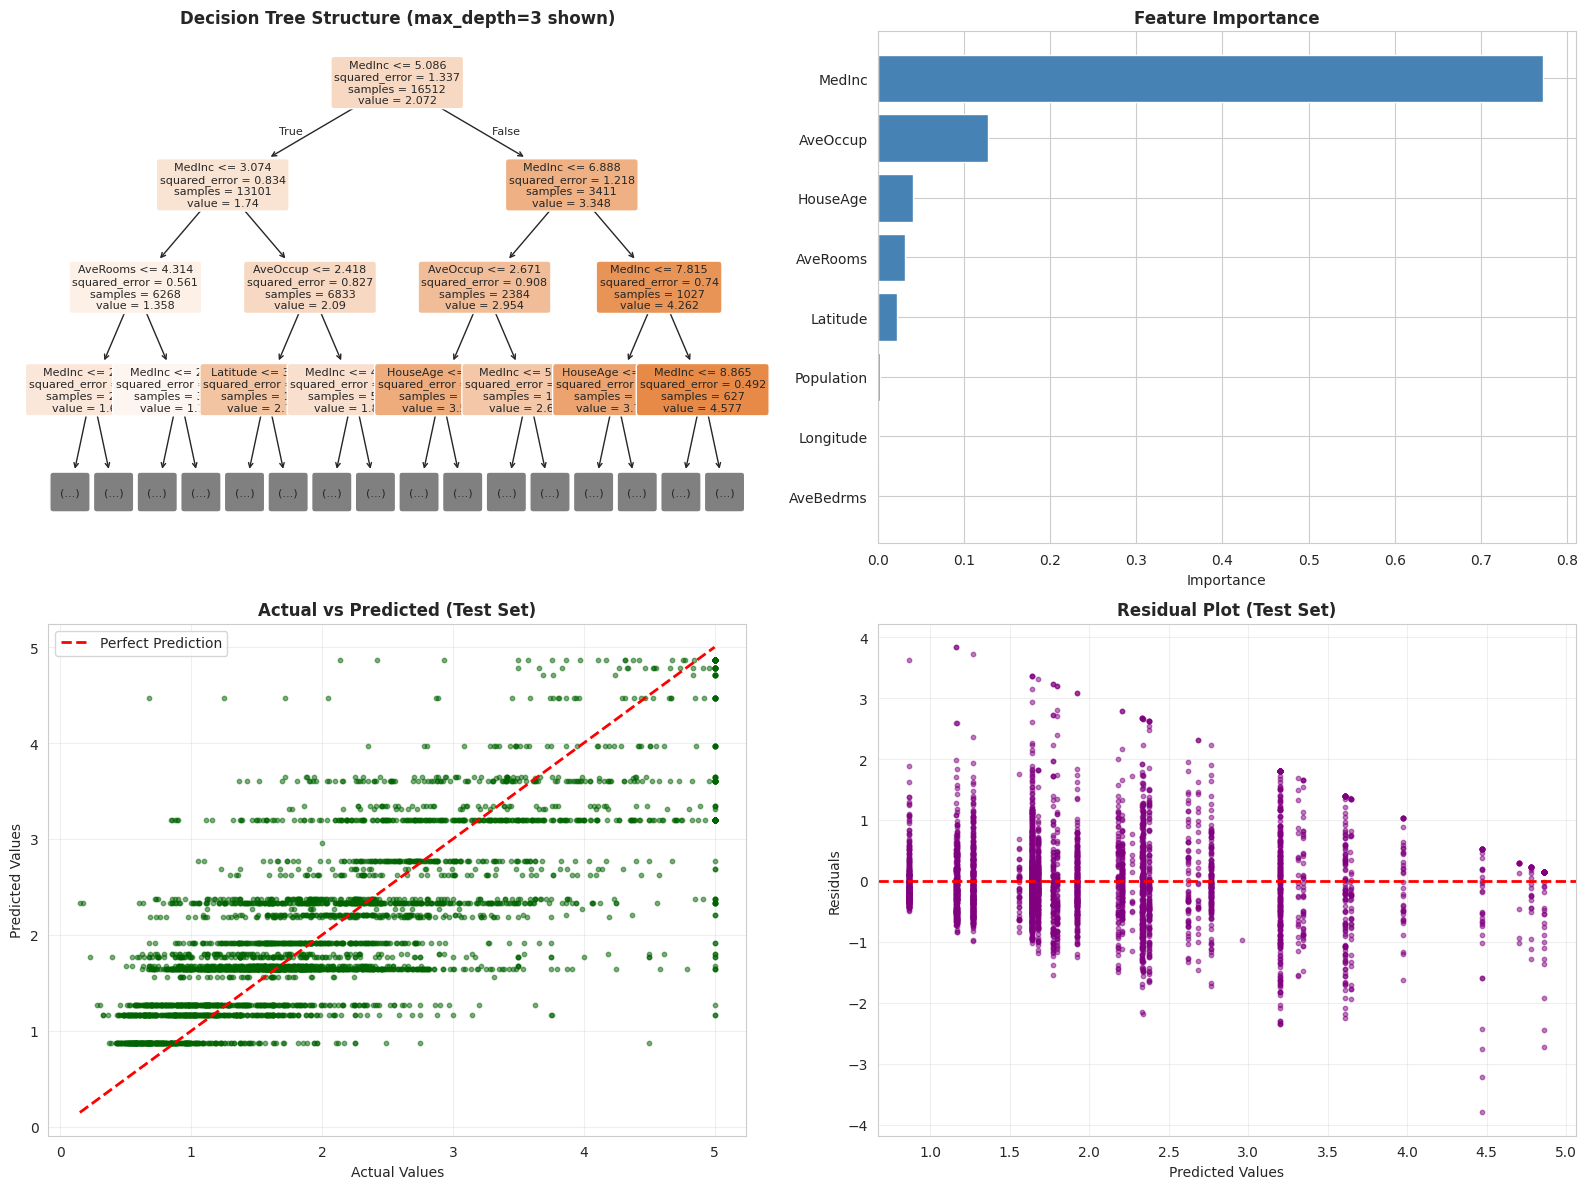


Example Prediction:

Input features:
{'MedInc': 1.6812, 'HouseAge': 25.0, 'AveRooms': 4.192200557103064, 'AveBedrms': 1.0222841225626742, 'Population': 1392.0, 'AveOccup': 3.8774373259052926, 'Latitude': 36.06, 'Longitude': -119.01}

Predicted house value: $116857.27
Actual house value: $47700.00
Difference: $69157.27

How Decision Trees Work for Regression:


In [22]:
dt_regressor.fit(X_train, y_train)

# Make predictions
y_train_pred = dt_regressor.predict(X_train)
y_test_pred = dt_regressor.predict(X_test)

# Evaluate model
print("\nModel Performance:")
print("-" * 50)
print(f"Training R² Score: {r2_score(y_train, y_train_pred):.4f}")
print(f"Testing R² Score: {r2_score(y_test, y_test_pred):.4f}")
print(f"\nTraining RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Testing RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"\nTraining MAE: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"Testing MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_regressor.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print("-" * 50)
print(feature_importance.to_string(index=False))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Decision Tree Structure (simplified view)
plot_tree(dt_regressor,
          feature_names=X.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=8,
          ax=axes[0, 0],
          max_depth=3)  # Show only first 3 levels for readability
axes[0, 0].set_title('Decision Tree Structure (max_depth=3 shown)', fontsize=12, fontweight='bold')

# 2. Feature Importance Bar Plot
axes[0, 1].barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
axes[0, 1].set_xlabel('Importance', fontsize=10)
axes[0, 1].set_title('Feature Importance', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. Actual vs Predicted (Test Set)
axes[1, 0].scatter(y_test, y_test_pred, alpha=0.5, s=10, color='darkgreen')
axes[1, 0].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Values', fontsize=10)
axes[1, 0].set_ylabel('Predicted Values', fontsize=10)
axes[1, 0].set_title('Actual vs Predicted (Test Set)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Residual Plot
residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, residuals, alpha=0.5, s=10, color='purple')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Values', fontsize=10)
axes[1, 1].set_ylabel('Residuals', fontsize=10)
axes[1, 1].set_title('Residual Plot (Test Set)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Example: Making predictions on new data
print("\n" + "="*50)
print("Example Prediction:")
print("="*50)
sample = X_test.iloc[0:1]
prediction = dt_regressor.predict(sample)
actual = y_test.iloc[0]

print(f"\nInput features:\n{sample.to_dict('records')[0]}")
print(f"\nPredicted house value: ${prediction[0]*100000:.2f}")
print(f"Actual house value: ${actual*100000:.2f}")
print(f"Difference: ${abs(prediction[0] - actual)*100000:.2f}")

print("\n" + "="*50)
print("How Decision Trees Work for Regression:")
print("="*50)